# 22 - Figures and tables

Last notebook. Regenerates every figure for the paper and the defence deck, plus the
CSV and LaTeX tables, from whatever is currently in `runs/`.

Everything is derived, nothing is typed by hand. Re-running this after any change to
`runs/` keeps the tables, the figures and the manuscript in agreement, which is the
only reliable way to stop a number in the text drifting away from the number in the
plot.

In [1]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATA = ROOT / "data"
RUNS = ROOT / "runs"
print("repo:", ROOT)

repo: /workspace/ham10000-cnn-comparison


In [2]:
import subprocess
for script in ["make_figures.py", "build_tables.py"]:
    print(f"===== {script} =====")
    r = subprocess.run([sys.executable, str(ROOT / "scripts" / script)],
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)

===== make_figures.py =====
Found 12 finished experiments: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12

  wrote figures/01_class_distribution.png and .pdf
  wrote figures/02_training_curves.png and .pdf
  wrote figures/03_per_class_f1_heatmap.png and .pdf
  wrote figures/04_confusion_matrices.png and .pdf
  wrote figures/05_melanoma_precision_recall.png and .pdf
  wrote figures/06_rq2_criterion.png and .pdf
  wrote figures/07_deployability.png and .pdf
  wrote figures/08_resolution_ablation.png and .pdf
  wrote figures/09_frequency_tiers.png and .pdf
  wrote figures/10_mcnemar.png and .pdf
  wrote figures/11_training_cost.png and .pdf

All figures are in /workspace/ham10000-cnn-comparison/figures

===== build_tables.py =====
Building tables from 12 runs

  tables/headline.csv and .tex
  tables/clinical.csv and .tex
  tables/per_class_f1.csv and .tex
  tables/rq_answers.json

{
  "best_mobilenet": "E3",
  "best_resnet": "E2",
  "f1_mel_mobilenet": 0.442424,
  "f1_mel_resnet": 0.47

## What came out

In [3]:
for f in sorted((ROOT / "figures").glob("*.png")):
    print(f"{f.name:<40} {f.stat().st_size/1e3:>7.0f} KB")
print()
for f in sorted((ROOT / "tables").glob("*")):
    print(f"  {f.name}")

01_class_distribution.png                     56 KB
02_training_curves.png                       597 KB
03_per_class_f1_heatmap.png                  162 KB
04_confusion_matrices.png                    377 KB
05_melanoma_precision_recall.png             130 KB
06_rq2_criterion.png                         150 KB
07_deployability.png                         106 KB
08_resolution_ablation.png                   155 KB
09_frequency_tiers.png                        86 KB
10_mcnemar.png                               115 KB
11_training_cost.png                          75 KB
eda_class_distribution.png                    57 KB
eda_sample_images.png                       3853 KB
eda_split_proportions.png                     49 KB

  .gitkeep
  clinical.csv
  clinical.tex
  headline.csv
  headline.tex
  per_class_f1.csv
  per_class_f1.tex
  rq_answers.json


### RQ answers, computed from the results rather than asserted

In [4]:
answers = json.loads((ROOT / "tables" / "rq_answers.json").read_text())
print(json.dumps(answers, indent=2))

{
  "rq1": {
    "best_mobilenet": "E3",
    "best_resnet": "E2",
    "f1_mel_mobilenet": 0.442424,
    "f1_mel_resnet": 0.479592,
    "gap": 0.037168,
    "threshold": 0.05,
    "passes": true,
    "macro_f1_best_alternative": {
      "best_mobilenet": "E5",
      "best_resnet": "E2",
      "gap": 0.026632,
      "passes": true
    }
  },
  "rq2": {
    "criterion": "mean(recall_MEL, recall_BCC)",
    "scores": {
      "E1": 0.588925,
      "E2": 0.515669,
      "E3": 0.64758,
      "E4": 0.377687,
      "E5": 0.548236,
      "E6": 0.351846,
      "E7": 0.639623,
      "E8": 0.501887,
      "E9": 0.664971,
      "E10": 0.599016,
      "E11": 0.771616,
      "E12": 0.562018
    },
    "best_per_architecture": {
      "mobilenet_v2": "E3",
      "resnet50": "E2",
      "efficientnet_b3": "E11"
    }
  },
  "notes": []
}


### The headline table

In [5]:
import pandas as pd
print(pd.read_csv(ROOT / "tables" / "headline.csv").to_string(index=False))

Exp    Architecture  Input            Strategy  Epochs  Accuracy  Balanced acc  Macro F1  Macro AUC
 E1     MobileNetV2    224   Augmentation only      38  0.800781      0.671452  0.664277   0.957520
 E2       ResNet-50    224   Augmentation only      46  0.796875      0.592075  0.627581   0.946210
 E3     MobileNetV2    224         Weighted CE      34  0.710938      0.743508  0.621706   0.944518
 E4       ResNet-50    224         Weighted CE      50  0.699219      0.557253  0.483386   0.929366
 E5     MobileNetV2    224 Random oversampling      30  0.794922      0.711777  0.681428   0.953658
 E6       ResNet-50    224 Random oversampling      16  0.724609      0.655718  0.527456   0.929607
 E7 EfficientNet-B3    224   Augmentation only      15  0.804688      0.637328  0.674211   0.955419
 E8 EfficientNet-B3    224         Weighted CE      21  0.740234      0.687187  0.614285   0.942927
 E9 EfficientNet-B3    224 Random oversampling      20  0.804688      0.761149  0.704281   0.958444


In [6]:
print(pd.read_csv(ROOT / "tables" / "clinical.csv").to_string(index=False))

Exp    Architecture  Input            Strategy  P (MEL)  R (MEL)  F1 (MEL)  P (BCC)  R (BCC)  F1 (BCC)  RQ2 score
 E1     MobileNetV2    224   Augmentation only 0.486239 0.460870  0.473214 0.678571 0.716981  0.697248   0.588925
 E2       ResNet-50    224   Augmentation only 0.580247 0.408696  0.479592 0.559322 0.622642  0.589286   0.515669
 E3     MobileNetV2    224         Weighted CE 0.339535 0.634783  0.442424 0.603448 0.660377  0.630631   0.647580
 E4       ResNet-50    224         Weighted CE 0.381818 0.547826  0.450000 0.407407 0.207547  0.275000   0.377687
 E5     MobileNetV2    224 Random oversampling 0.484127 0.530435  0.506224 0.681818 0.566038  0.618557   0.548236
 E6       ResNet-50    224 Random oversampling 0.666667 0.156522  0.253521 0.537037 0.547170  0.542056   0.351846
 E7 EfficientNet-B3    224   Augmentation only 0.485915 0.600000  0.536965 0.750000 0.679245  0.712871   0.639623
 E8 EfficientNet-B3    224         Weighted CE 0.353846 0.400000  0.375510 0.666667 0.60

### Display the main figures inline

Handy when writing up, so the figure can be checked against the table on the same
screen.

06_rq2_criterion


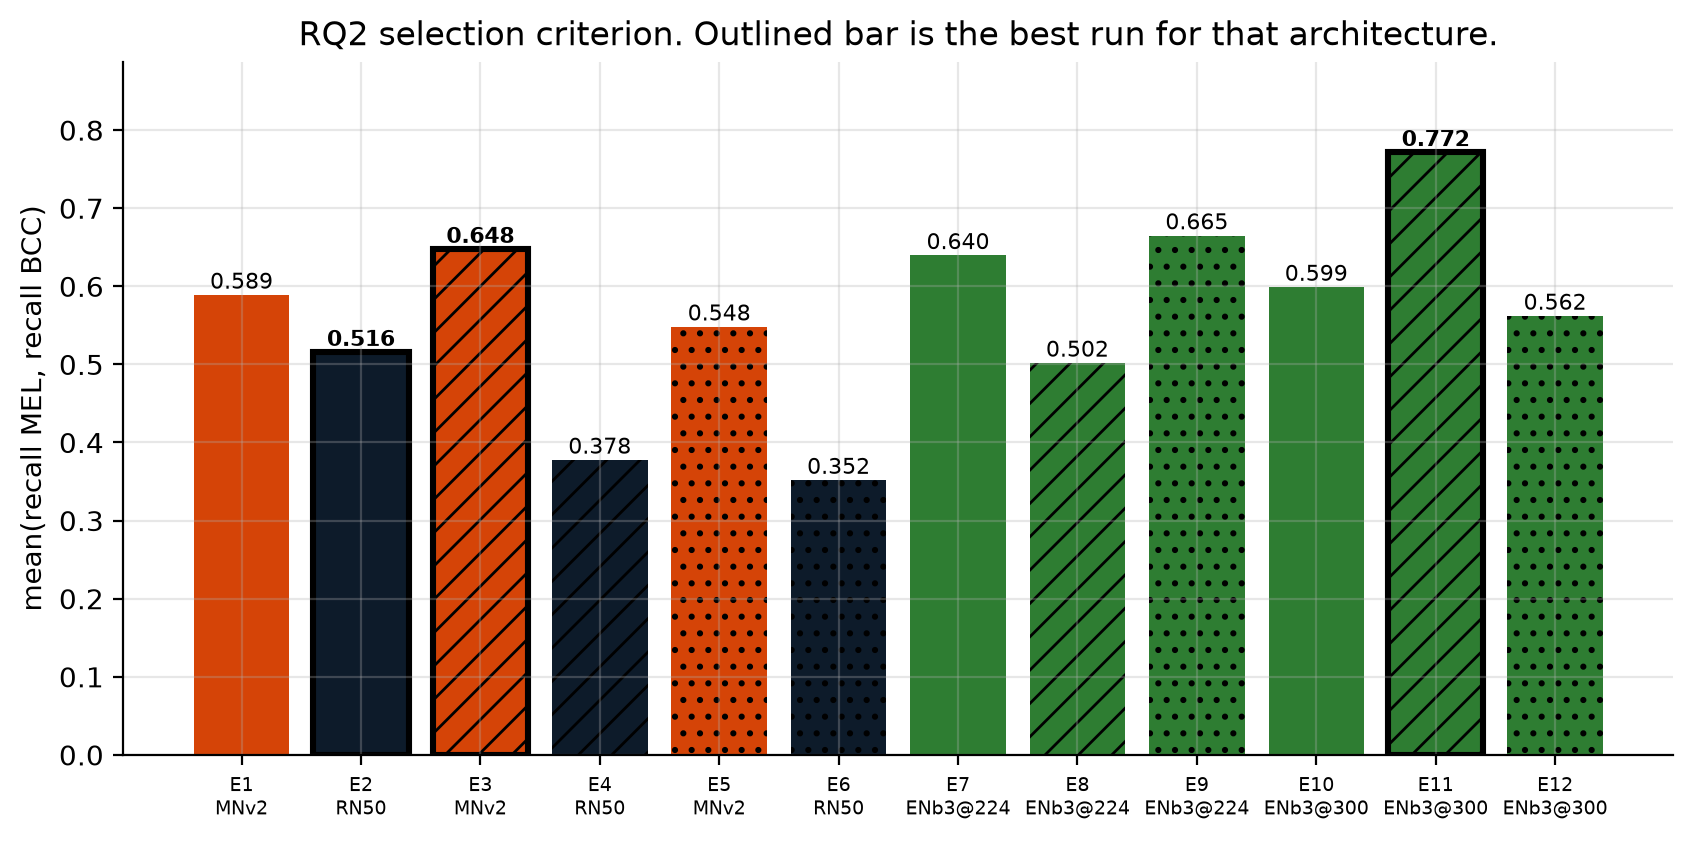

05_melanoma_precision_recall


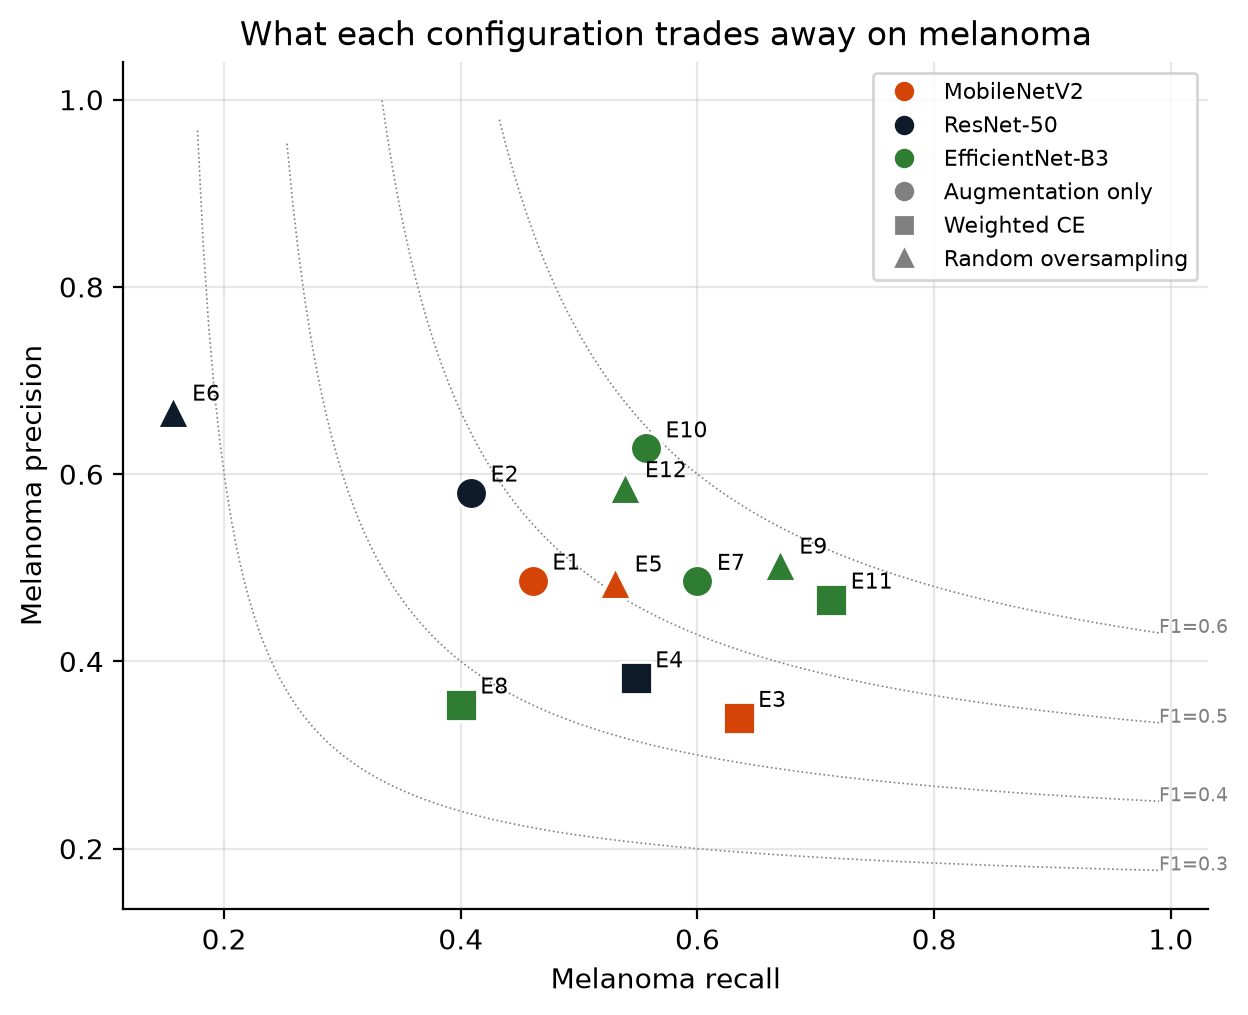

07_deployability


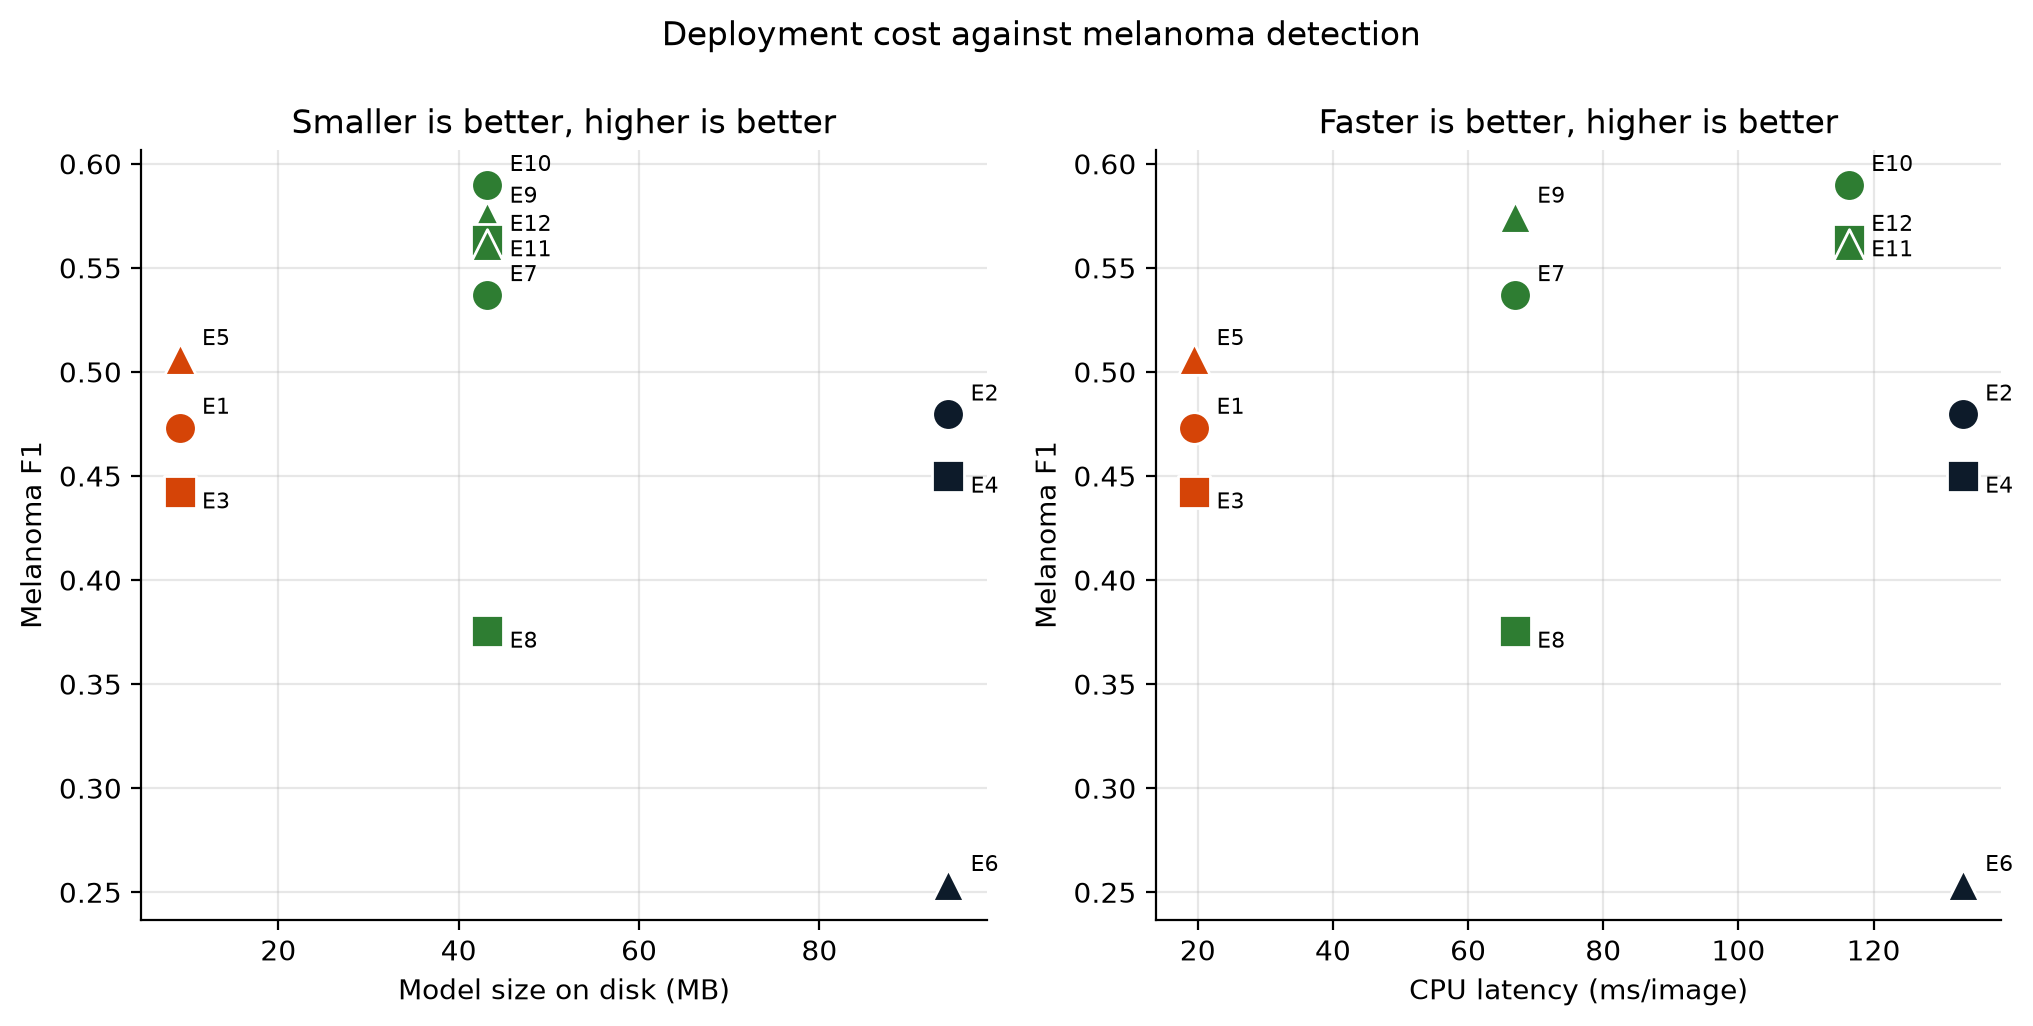

08_resolution_ablation


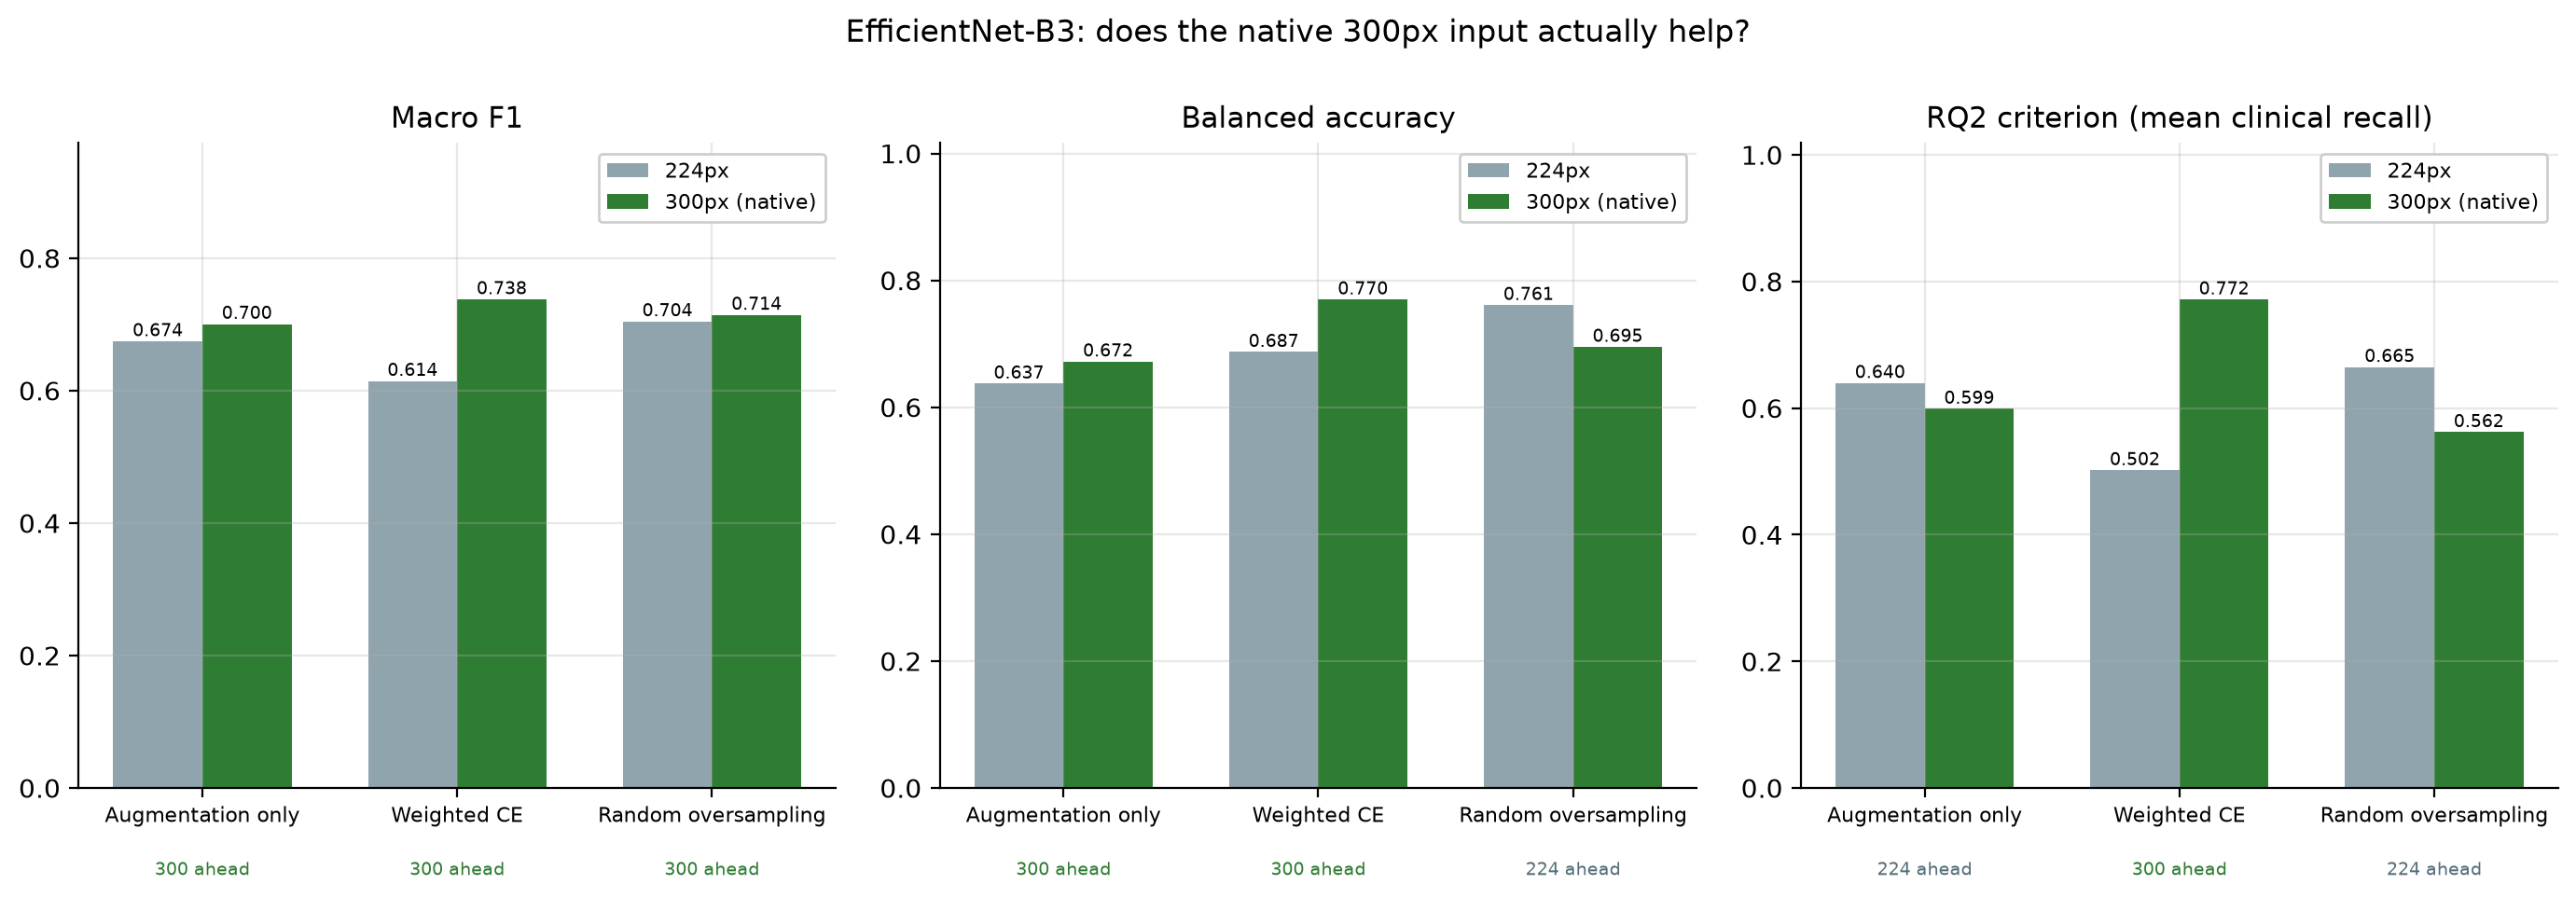

10_mcnemar


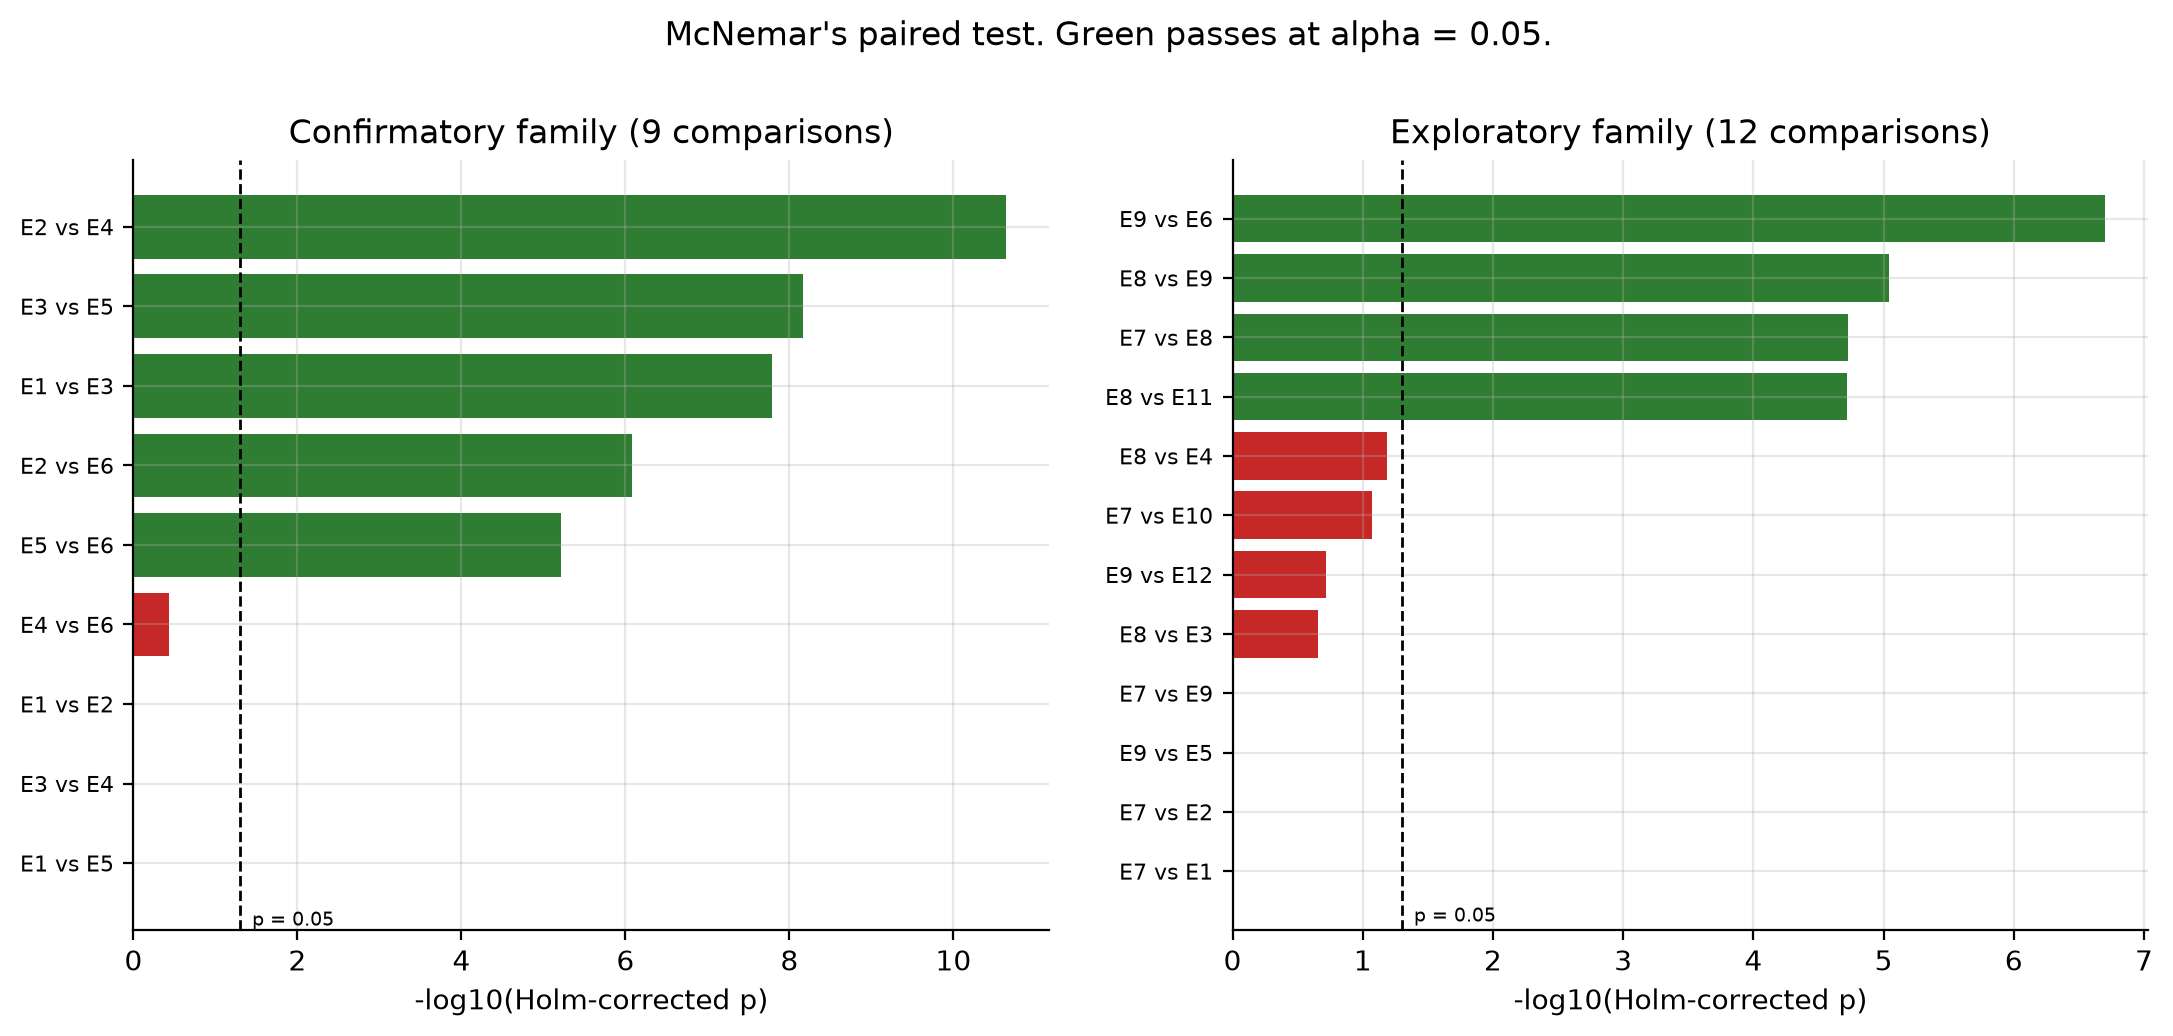

In [7]:
from IPython.display import Image, display

for name in ["06_rq2_criterion", "05_melanoma_precision_recall",
             "07_deployability", "08_resolution_ablation", "10_mcnemar"]:
    p = ROOT / "figures" / f"{name}.png"
    if p.exists():
        print(name)
        display(Image(filename=str(p), width=900))